## Эксперименты с моделями

Задача: регрессия

Таргет-метрика: `success_proxy_score`

Рассчитывается по формуле: `success_proxy_score = 0.65 * rating_norm + 0.35 * reviews_log_norm`

Где:

- `rating_norm = (Рейтинг - 1) / 4`;
- `reviews_log_norm = log1p(Оценок) / log1p(max(Оценок))`.

In [18]:
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

DATA_PATH = Path("../data/processed/products_processed.csv")

In [19]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (1454, 43)


,Артикул,success_proxy_score,Бренд,Название,Категория,Спец. цена,Цена,Старая цена,Скидка,Цвет,...,special_price_log1p,old_price_log1p,discount_ratio_calc,price_to_old_price_ratio,images_count_log1p,has_images,many_images,brand_frequency,seller_frequency,category_frequency
0,144542463,0.905121,X-Plode,Летние кеды тканевые дышащие,Обувь / Кеды,1461.0,1491,3888.0,61.0,"серый, белый",...,7.287561,8.265907,0.616512,0.383488,2.397895,1,1,0.027709,0.027709,0.99359
1,204459429,0.848275,Strobbs,Кеды мужские весенние,Обувь / Кеды,5639.0,5755,11990.0,52.0,серый,...,8.637639,9.391912,0.520017,0.479983,2.397895,1,1,0.000620,0.000620,0.99359
2,65828833,0.950545,X-Plode,Джинсовые летние кеды тканевые,Обувь / Кеды,1206.0,1231,3210.0,61.0,"синий, белый",...,7.095893,8.074338,0.616511,0.383489,2.397895,1,1,0.027709,0.027709,0.99359
3,225083731,0.873602,Vans,Кеды низкие повседневные,Обувь / Кеды,1854.0,1892,2500.0,24.0,"черный, белый",...,7.525640,7.824446,0.243200,0.756800,1.609438,1,0,0.001034,0.000207,0.99359
4,549184075,0.836232,X-Plode,Тканевые кеды летние дышащие,Обувь / Кеды,2034.0,2076,5414.0,61.0,красный,...,7.618251,8.596928,0.616550,0.383450,2.397895,1,1,0.027709,0.027709,0.99359


## 1. Признаки

In [ ]:
target_col = "success_proxy_score"
id_columns = ["Артикул"]

text_features = ["Название", "Описание", "Состав"]

excluded_columns = set([target_col] + id_columns + text_features)

numeric_features = [
    col for col in df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(df[col])
]
categorical_features = [
    col for col in df.columns
    if col not in excluded_columns and not pd.api.types.is_numeric_dtype(df[col])
]
text_features_present = [c for c in text_features if c in df.columns]

print("Числовые признаки:", len(numeric_features))
print("Категориальные признаки:", len(categorical_features))
print("Текстовые признаки (не используем в baseline):", text_features_present)

Числовые признаки: 26
Категориальные признаки: 12
Текстовые признаки (не используем в baseline): ['Название', 'Описание', 'Состав']


Рассмотрим распределение таргет-метрики.

,success_proxy_score
count,1454.000000
mean,0.748938
std,0.065614
min,0.447288
25%,0.701785
50%,0.748207
75%,0.795707
max,0.954354


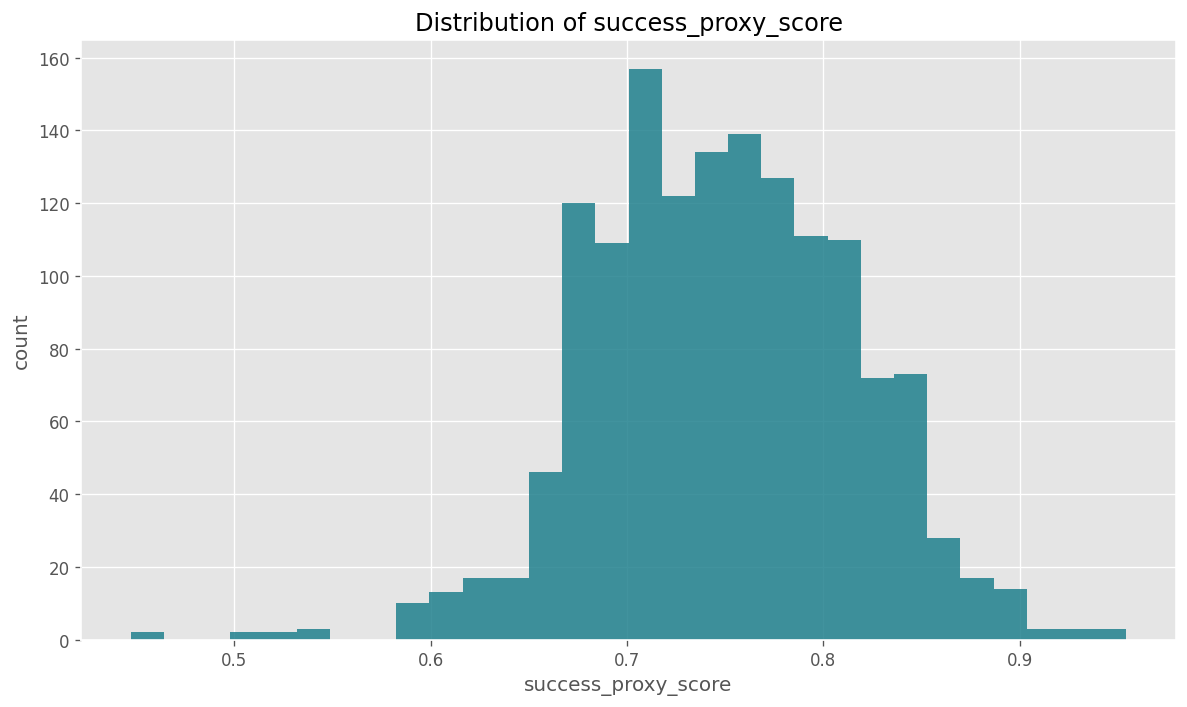

In [21]:
target_stats = df[target_col].describe().to_frame("success_proxy_score")
display(target_stats)

ax = df[target_col].hist(bins=30, color="#20808D", alpha=0.85)
ax.set_title("Distribution of success_proxy_score")
ax.set_xlabel("success_proxy_score")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

Теперь посмотрим признаки, которые будем использовать для обучения моделей в наших экспериментах.

In [22]:
features_for_baseline = numeric_features + categorical_features

X = df[features_for_baseline].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features before one-hot:", len(features_for_baseline))

display(pd.DataFrame({
    "feature": features_for_baseline,
    "type": ["numeric"] * len(numeric_features) + ["categorical"] * len(categorical_features),
}).head(50))

X shape: (1454, 38)
y shape: (1454,)
Number of features before one-hot: 38


,feature,type
0,Спец. цена,numeric
1,Цена,numeric
2,Старая цена,numeric
3,Скидка,numeric
4,Кол-во картинок,numeric
5,name_len,numeric
6,name_word_count,numeric
7,description_len,numeric
8,description_word_count,numeric
9,description_missing,numeric


## 2. Train/Validation/Test
Делим данные в пропорции 70/15/15 из-за небольшого датасета. Так как наша задача - регрессия, то распределения по классу нет, но чтобы таргет-метрика во всех выборках была примерно одинаково распределена, создадим временные бины для таргета и используем их для равномерного разбиения.

In [23]:
target_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_temp, y_train, y_temp, bins_train, bins_temp = train_test_split(
    X,
    y,
    target_bins,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=target_bins,
)

temp_bins = pd.qcut(y_temp, q=5, labels=False, duplicates="drop")

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_bins,
)

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(X_train), "target_mean": y_train.mean(), "target_std": y_train.std()},
    {"split": "validation", "rows": len(X_val), "target_mean": y_val.mean(), "target_std": y_val.std()},
    {"split": "test", "rows": len(X_test), "target_mean": y_test.mean(), "target_std": y_test.std()},
])

split_summary

,split,rows,target_mean,target_std
0,train,1017,0.749362,0.065992
1,validation,218,0.748309,0.065101
2,test,219,0.747593,0.064627


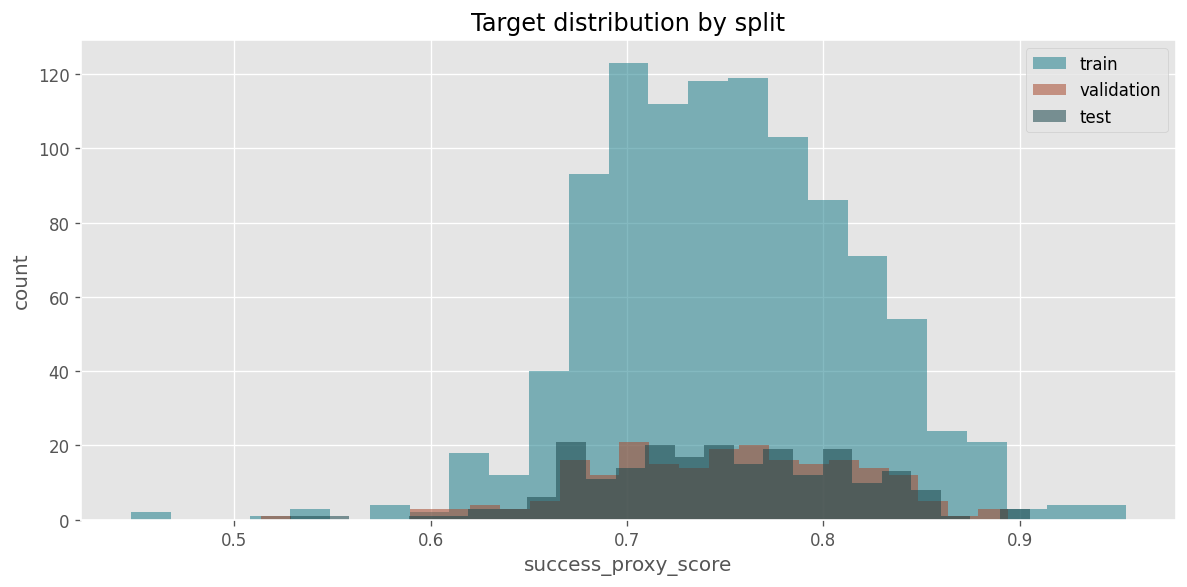

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_train, bins=25, alpha=0.55, label="train", color="#20808D")
ax.hist(y_val, bins=25, alpha=0.55, label="validation", color="#A84B2F")
ax.hist(y_test, bins=25, alpha=0.55, label="test", color="#1B474D")
ax.set_title("Target distribution by split")
ax.set_xlabel("success_proxy_score")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Предобработка для моделей

Используем `ColumnTransformer`:

Для числовых признаков: пропуски заполняем медианой, масштабируем через `StandartScaler`.

Для категориальных признаков: пропуски заполняем значением `__MISSING__`, кодируем через `OneHotEncoder`. 

In [25]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

## 4. Метрики

Будем использовать стандартные метрики качества для регрессионых задач:

- MAE: средняя абсолютная ошибка. Будем считать её основной метрикой качества.
- RMSE: сильнее штрафует модель за большие ошибки.
- $R^2$: показывает долю объяснённой дисперсии.
- Spearman: показывает, насколько хорошо модель расставляет карточки по успешности.

In [26]:
def regression_metrics(y_true, y_pred) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    spearman = spearmanr(y_true, y_pred).correlation
    if pd.isna(spearman):
        spearman = None
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Spearman": spearman,
    }


def evaluate_model(name: str, model, X_train, y_train, X_val, y_val) -> tuple[Pipeline, dict]:
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    val_pred = pipe.predict(X_val)
    metrics = regression_metrics(y_val, val_pred)
    metrics["model"] = name
    return pipe, metrics

## 5. Обучение моделей
Сравниваем простые модели и ансамбли: DummyRegressor, LinearRegression, Ridge, KNN, RandomForest, XGBoost, LightGBM. DummyRegressor всегда предсказывает среднее значение таргет-метрики, поэтому его мы используем просто для оценки валидности признаков для обучения.

In [27]:
models = {
    "DummyMean": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_SEED),
    "KNN_5": KNeighborsRegressor(n_neighbors=5, weights="distance"),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=100, 
        max_depth=6, 
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=100, 
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1
    )
}

trained_models = {}
validation_rows = []

for name, model in models.items():
    pipe, metrics = evaluate_model(name, model, X_train, y_train, X_val, y_val)
    trained_models[name] = pipe
    validation_rows.append(metrics)

validation_results = pd.DataFrame(validation_rows).sort_values("MAE")
display(validation_results)

C:\Users\yashi\AppData\Local\Temp\ipykernel_616\134725574.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman = spearmanr(y_true, y_pred).correlation
d:\machine_learning_wb\hseml-group-project-hesgenius\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2,Spearman,model
5,0.037228,0.050886,0.386195,0.645671,XGBoost
6,0.037390,0.049604,0.416731,0.665449,LightGBM
4,0.038309,0.051326,0.375553,0.670593,RandomForest
3,0.039860,0.053926,0.310682,0.605368,KNN_5
2,0.041180,0.053814,0.313523,0.604748,Ridge
0,0.052894,0.064960,-0.000263,NaN,DummyMean
1,0.057402,0.130705,-3.049626,0.493520,LinearRegression


Проверим обученные модели на выборке validation.

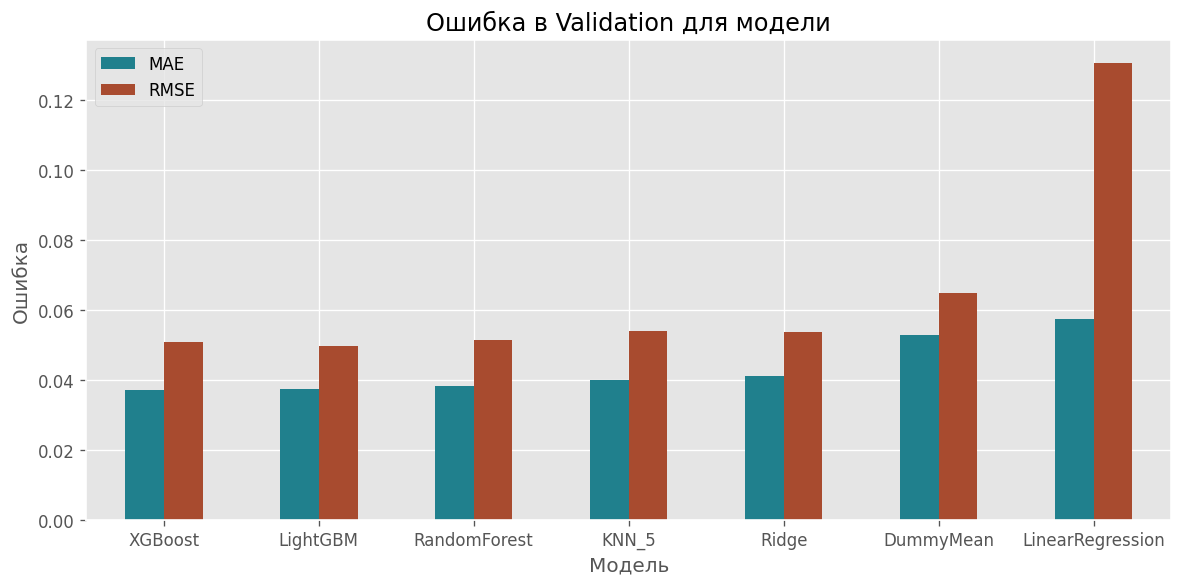

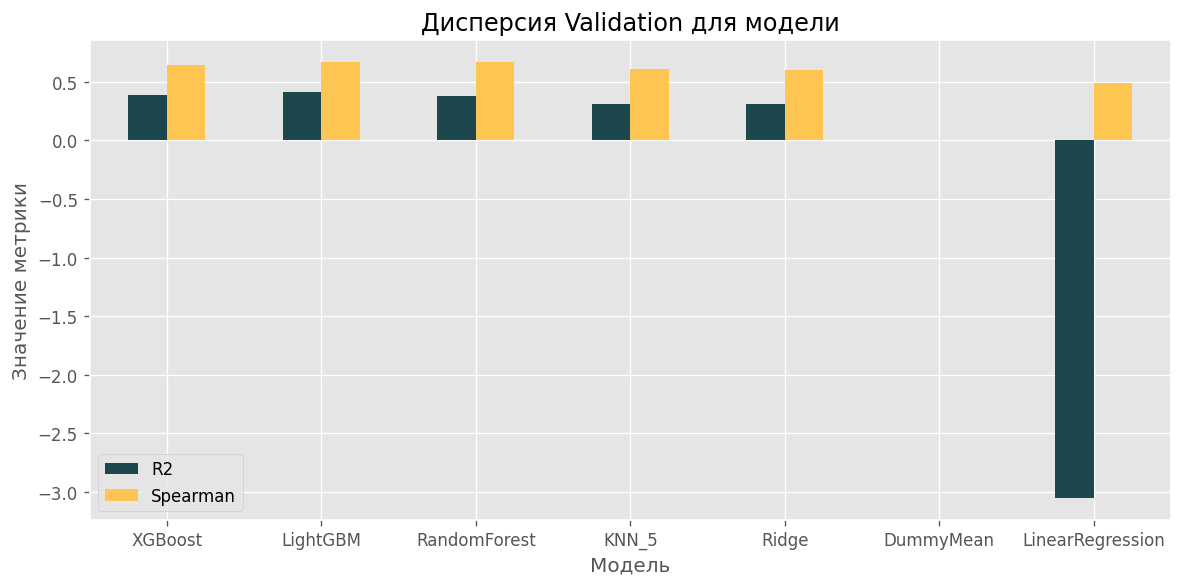

In [28]:
ax = validation_results.set_index("model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#20808D", "#A84B2F"],
)
ax.set_title("Ошибка в Validation для модели")
ax.set_ylabel("Ошибка")
ax.set_xlabel("Модель")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ax = validation_results.set_index("model")[["R2", "Spearman"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#1B474D", "#FFC553"],
)
ax.set_title("Дисперсия Validation для модели")
ax.set_ylabel("Значение метрики")
ax.set_xlabel("Модель")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5.1 Уменьшение размерности (PCA)

Поскольку после One-Hot Encoding признаков становится много, попробуем использовать метод главных компонент (PCA) для уменьшения размерности перед обучением модели. Посмотрим, сколько компонент необходимо для сохранения 90% дисперсии.

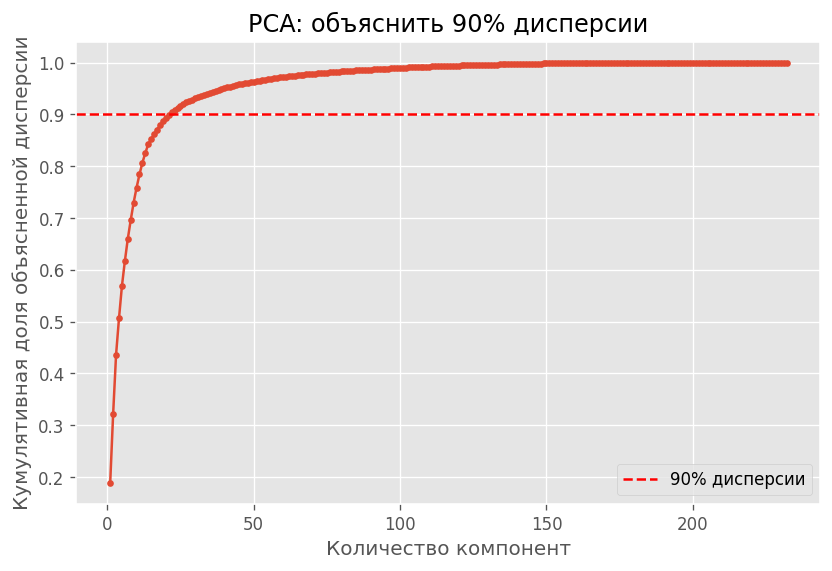

Для сохранения 90% дисперсии нужно 22 компонент.
Результат модели с PCA на Validation: 0.0393354184792439


In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)

pca = PCA(random_state=RANDOM_SEED)
pca.fit(X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker=".")
plt.axhline(y=0.9, color="r", linestyle="--", label="90% дисперсии")
plt.xlabel("Количество компонент")
plt.ylabel("Кумулятивная доля объясненной дисперсии")
plt.title("PCA: объяснить 90% дисперсии")
plt.legend()
plt.show()

n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Для сохранения 90% дисперсии нужно {n_components_90} компонент.")

pca_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=n_components_90, random_state=RANDOM_SEED)),
    ("model", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_SEED, n_jobs=-1)),
])
pca_pipe.fit(X_train, y_train)
pca_pred = pca_pipe.predict(X_val)
pca_metrics = regression_metrics(y_val, pca_pred)
pca_metrics["model"] = "RandomForest + PCA"
print("Результат модели с PCA на Validation:", pca_metrics["MAE"])

## 5.2 Перебор гиперпараметров (Optuna)

Проведем легкий тюнинг гиперпараметров для наиболее перспективной модели (LightGBM или XGBoost) с помощью Optuna.

In [30]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.5, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "random_state": RANDOM_SEED,
        "verbose": -1,
        "n_jobs": -1
    }
    
    model = lgb.LGBMRegressor(**params)
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    return mae

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=20)

print("Лучшие параметры:", study.best_params)
print("Лучшее MAE на валидации:", study.best_value)

best_lgbm = lgb.LGBMRegressor(**study.best_params, random_state=RANDOM_SEED, verbose=-1, n_jobs=-1)
best_lgbm_pipe, tuned_metrics = evaluate_model("LightGBM_Tuned", best_lgbm, X_train, y_train, X_val, y_val)
validation_results = pd.concat([validation_results, pd.DataFrame([tuned_metrics])], ignore_index=True).sort_values("MAE")
validation_results

d:\machine_learning_wb\hseml-group-project-hesgenius\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\machine_learning_wb\hseml-group-project-hesgenius\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\machine_learning_wb\hseml-group-project-hesgenius\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\machine_learning_wb\hseml-group-project-hesgenius\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\machine_learning_wb\hseml-group-project-hesgenius\venv\Lib\site-packages\sklearn\utils\validation

Лучшие параметры: {'n_estimators': 64, 'learning_rate': 0.21766241123453672, 'max_depth': 9}
Лучшее MAE на валидации: 0.036773163897614994


d:\machine_learning_wb\hseml-group-project-hesgenius\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\machine_learning_wb\hseml-group-project-hesgenius\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2,Spearman,model
7,0.036773,0.049348,0.422752,0.673039,LightGBM_Tuned
0,0.037228,0.050886,0.386195,0.645671,XGBoost
1,0.037390,0.049604,0.416731,0.665449,LightGBM
2,0.038309,0.051326,0.375553,0.670593,RandomForest
3,0.039860,0.053926,0.310682,0.605368,KNN_5
4,0.041180,0.053814,0.313523,0.604748,Ridge
5,0.052894,0.064960,-0.000263,NaN,DummyMean
6,0.057402,0.130705,-3.049626,0.493520,LinearRegression


## 6. Оценка на тестовой выборке

Выбираем модель с наилучшим MAE на валидационной выборке и проверяем её на тестовых данных, чтобы убедиться в отсутствии переобучения.

In [ ]:
best_model_name = validation_results.iloc[0]["model"]

if best_model_name == "LightGBM_Tuned":
    best_pipe = best_lgbm_pipe
elif best_model_name == "RandomForest + PCA":
    best_pipe = pca_pipe
else:
    best_model = models[best_model_name]
    best_pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", best_model),
    ])

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

best_pipe.fit(X_train_val, y_train_val)
test_pred = best_pipe.predict(X_test)
test_metrics = regression_metrics(y_test, test_pred)

print("Лучшая модель:", best_model_name)
display(pd.DataFrame([{**{"модель": best_model_name}, **test_metrics}]))

Лучшая модель: LightGBM_Tuned


d:\machine_learning_wb\hseml-group-project-hesgenius\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,модель,MAE,RMSE,R2,Spearman
0,LightGBM_Tuned,0.038926,0.049998,0.398746,0.648212


,count,mean,std,min,25%,50%,75%,max
y_true,219.0,0.747593,0.064627,0.528538,0.701785,0.747382,0.797646,0.905121
y_pred,219.0,0.747399,0.045821,0.649106,0.711002,0.748687,0.779953,0.903098
error,219.0,-0.000194,0.050112,-0.116694,-0.033036,-0.003514,0.033352,0.203665
abs_error,219.0,0.038926,0.031449,0.000368,0.014466,0.033530,0.055533,0.203665


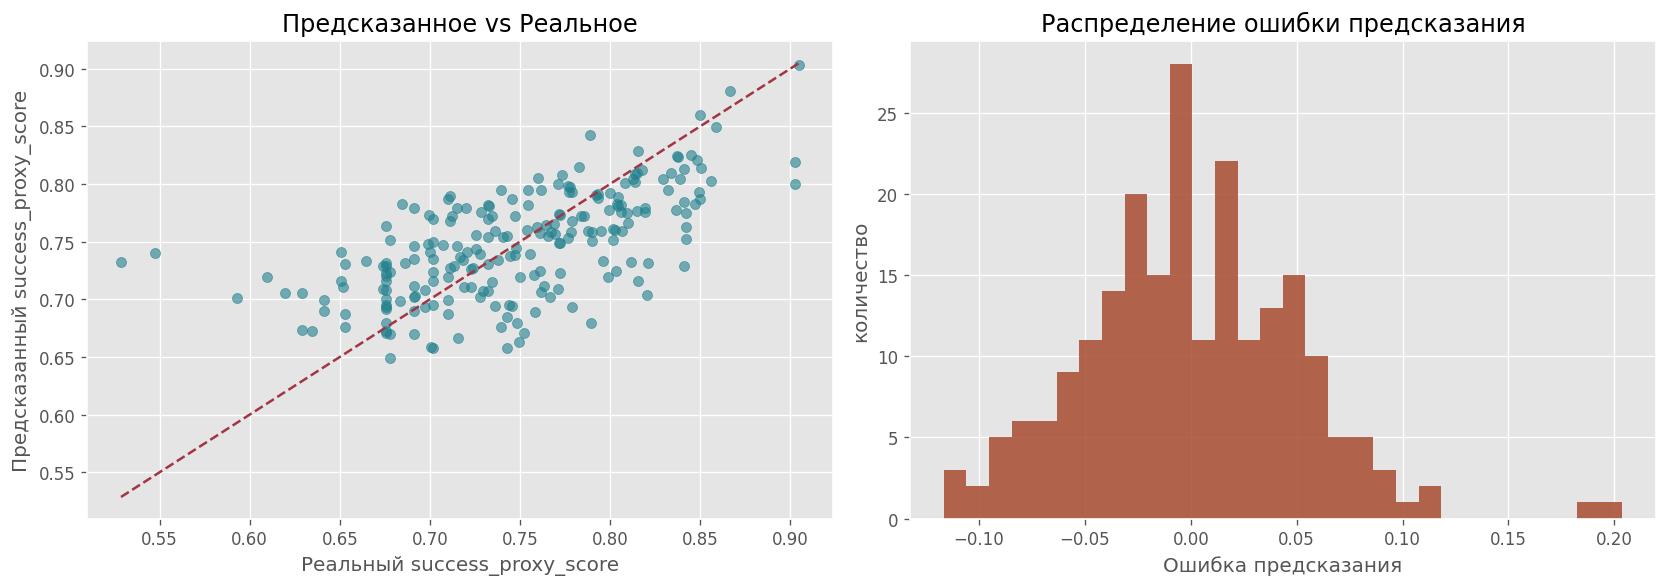

In [32]:
predictions_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": test_pred,
    "error": test_pred - y_test,
    "abs_error": np.abs(test_pred - y_test),
})

display(predictions_df.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(predictions_df["y_true"], predictions_df["y_pred"], alpha=0.6, color="#20808D")
min_val = min(predictions_df["y_true"].min(), predictions_df["y_pred"].min())
max_val = max(predictions_df["y_true"].max(), predictions_df["y_pred"].max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="#A13544", linestyle="--")
axes[0].set_title("Предсказанное vs Реальное")
axes[0].set_xlabel("Реальный success_proxy_score")
axes[0].set_ylabel("Предсказанный success_proxy_score")

axes[1].hist(predictions_df["error"], bins=30, color="#A84B2F", alpha=0.85)
axes[1].set_title("Распределение ошибки предсказания")
axes[1].set_xlabel("Ошибка предсказания")
axes[1].set_ylabel("количество")

plt.tight_layout()
plt.show()

## 7. Вывод
В этом ноутбуке мы разбирали более сложные модели (`XGBoost`, `LightGBM`), использовали PCA для анализа структуры данных и уменьшения размерности при сохранении 90% дисперсии.Благодаря уменьшению размерности мы можем ускорять обучение и бороться с переобучением (если например массив данных сильно разрежен из-за `OneHotEncoder`). Для перебора гиперпараметров использовали `optuna`.
Лучшая модель по результатам метрики MAE - `LightGBM_Tuned`.